# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

In [11]:
from PIL import Image, ImageDraw
from IPython.display import Image as IPImage, display
import os

In [12]:
# === Change these if you want ===
size = 512              # image size (square)
square_size = 120       # side length of the black square in pixels
left_shift = 120        # how many pixels to move the square left in the second image

bg_color = (255, 255, 255)   # white
square_color = (0, 0, 0)     # black

output1 = "square_centered.png"
output2 = "square_left.png"
# =================================

In [13]:
half = square_size // 2
center = size // 2

# --- Image 1: Centered square ---
img1 = Image.new('RGB', (size, size), bg_color)
draw1 = ImageDraw.Draw(img1)
draw1.rectangle(
    [center - half, center - half, center + half, center + half],
    fill=square_color
)
img1.save(output1)
print(f"✅ Saved {output1}")

# --- Image 2: Square moved to the left ---
img2 = Image.new('RGB', (size, size), bg_color)
draw2 = ImageDraw.Draw(img2)
draw2.rectangle(
    [center - half - left_shift, center - half,
     center + half - left_shift, center + half],
    fill=square_color
)
img2.save(output2)
print(f"✅ Saved {output2}")

print(f"\nBoth images are {size}×{size} pixels.")

✅ Saved square_centered.png
✅ Saved square_left.png

Both images are 512×512 pixels.


Centered square:


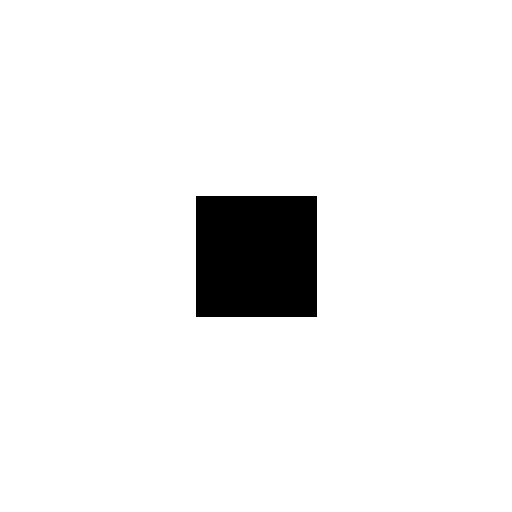

Square shifted left:


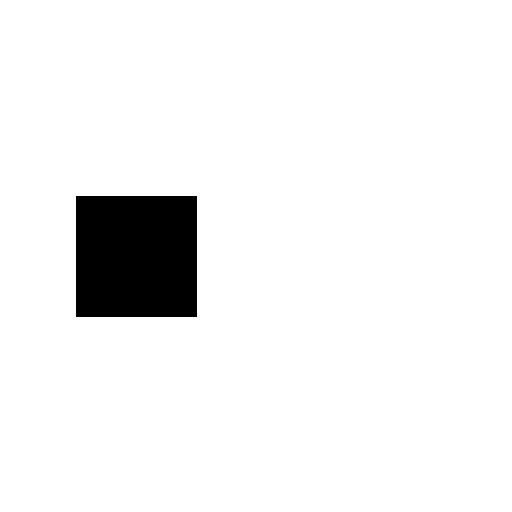

In [14]:
print("Centered square:")
display(IPImage(output1))

print("Square shifted left:")
display(IPImage(output2))

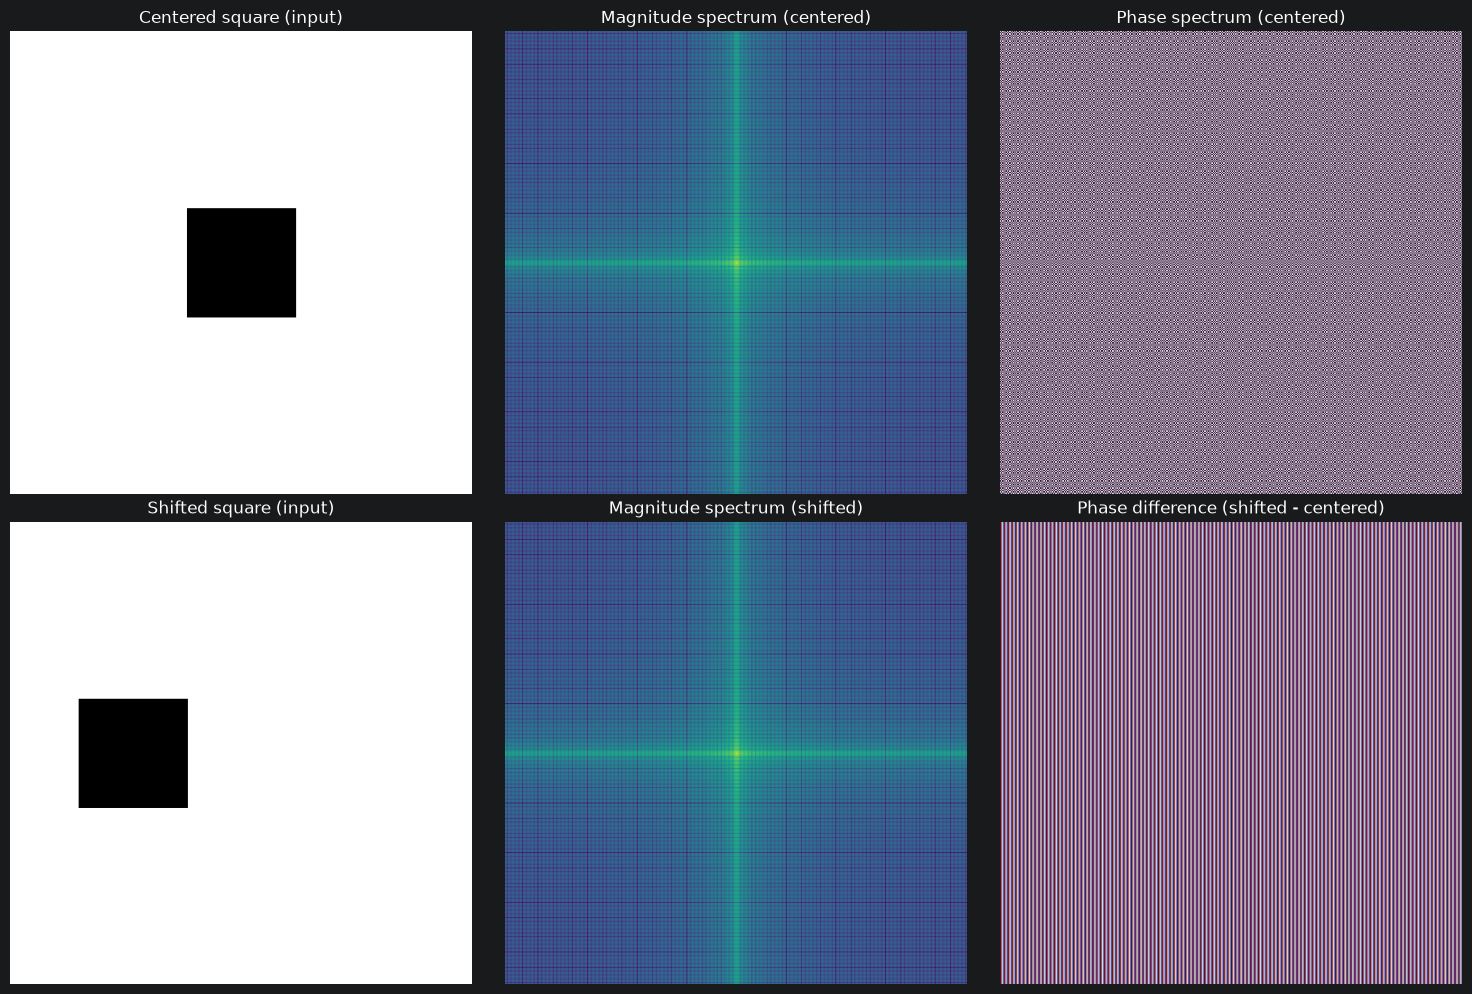

Max magnitude difference between spectra: 0.0000
Mean absolute phase difference: 1.5708 rad


In [15]:
# Convert both images to grayscale arrays and compute their 2D Fourier transforms.
# We then visualize the magnitude and phase spectra to compare how shifting the
# square affects the frequency domain representation (the shift theorem predicts
# the magnitude stays the same while the phase changes).

import numpy as np
import matplotlib.pyplot as plt

# Load the two images and convert to grayscale numpy arrays
square1 = np.asarray(Image.open(output1).convert('L'), dtype=float)
square2 = np.asarray(Image.open(output2).convert('L'), dtype=float)

# Compute 2D FFT and shift zero-frequency component to the center
fft1 = np.fft.fftshift(np.fft.fft2(square1))
fft2 = np.fft.fftshift(np.fft.fft2(square2))

# Magnitude (log-scaled for visibility) and phase spectra
mag1 = np.log1p(np.abs(fft1))
mag2 = np.log1p(np.abs(fft2))
phase1 = np.angle(fft1)
phase2 = np.angle(fft2)

# Difference in phase between the two images
phase_diff = np.angle(fft2 / fft1)

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(square1, cmap='gray')
axes[0, 0].set_title('Centered square (input)')
axes[0, 1].imshow(mag1, cmap='viridis')
axes[0, 1].set_title('Magnitude spectrum (centered)')
axes[0, 2].imshow(phase1, cmap='twilight')
axes[0, 2].set_title('Phase spectrum (centered)')

axes[1, 0].imshow(square2, cmap='gray')
axes[1, 0].set_title('Shifted square (input)')
axes[1, 1].imshow(mag2, cmap='viridis')
axes[1, 1].set_title('Magnitude spectrum (shifted)')
axes[1, 2].imshow(phase_diff, cmap='twilight')
axes[1, 2].set_title('Phase difference (shifted - centered)')

for ax in axes.ravel():
    ax.axis('off')

plt.tight_layout()
plt.show()

print(f"Max magnitude difference between spectra: {np.max(np.abs(mag1 - mag2)):.4f}")
print(f"Mean absolute phase difference: {np.mean(np.abs(phase_diff)):.4f} rad")


Saves the Fourier analysis figure to a PNG file.



In [16]:
fig.savefig("fourier_analysis.png", dpi=150, bbox_inches="tight")
print("✅ Saved fourier_analysis.png")


✅ Saved fourier_analysis.png
